In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2, QiskitRuntimeService
import numpy as np
from tqdm import tqdm

QiskitRuntimeService.save_account(
token="ezWDWhMPkm4EKsFC8iq2dvRIWPe4H8-e3IIm0oVx_3ba", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance="crn:v1:bluemix:public:quantum-computing:us-east:a/df0456804203486e9cb63132d6fe45ec:bcbc0e1e-a0e7-42e3-b260-4b8f9d934c86::", # Optional
overwrite=True
)

In [3]:
cliffords = [
    'I', 'X', 'Y', 'Z', 'S', 's',
    'H', 'XH', 'YH', 'ZH', 'SH', 'sH',
    'XS', 'YS', 'HX', 'HY', 'HS', 'Hs',
    'XSH', 'YSH', 'ZSH', 'XsH', 'sXH', 'XHSX'
]
def apply_gate(qc, gate):
    if gate == 'I':
        qc.id(0)
    elif gate == 'X':
        qc.x(0)
    elif gate == 'Y':
        qc.y(0)
    elif gate == 'Z':
        qc.z(0)
    elif gate == 'S':
        qc.s(0)
    elif gate == 's':
        qc.sdg(0)
    elif gate == 'H':   
        qc.h(0)

def apply_clifford(qc, clifford):
    for i in range(len(clifford) - 1, -1, -1):
        apply_gate(qc, clifford[i])
def apply_clifford_adjoint(qc, clifford):
    for i in range(0, len(clifford), 1):
        if clifford[i] == 'S':
            apply_gate(qc, 's')
        elif clifford[i] == 's':
            apply_gate(qc, 'S')
        else:
            apply_gate(qc, clifford[i])
        



['XsH', 'Y', 'sXH', 'sH', 'XS', 'YSH', 'HS', 'YSH', 'I', 'XHSX', 'Y', 'XS', 'H', 'Z', 'sXH', 'HS', 'HX', 'XHSX', 'sH', 'HS', 'SH', 'YS', 'HS', 'ZSH', 'H', 'YS', 'ZSH', 'ZH', 'YSH', 's', 'YS', 'XH', 'XS', 's', 'SH', 'H', 'sH', 'YSH', 'S', 's', 'YH', 'YH', 'Hs', 'X', 's', 'XSH', 'SH', 'SH', 'Y', 'HX', 'YH', 'sXH', 'H', 'X', 'I', 'sXH', 'HS', 'S', 'SH', 'XS', 'Z', 'Z', 'Y', 'XSH', 'sH', 'X', 'HS', 'XHSX', 'sXH', 'Y', 's', 'HX', 'SH', 'sH', 'HS', 'YH', 'XS', 'YH', 'XHSX', 'I', 'Y', 'ZSH', 'XHSX', 'Z', 'sH', 'S', 'I', 'Z', 'YH', 'I', 'ZH', 'XHSX', 'SH', 'XsH', 'ZSH', 'Z', 'sH', 'ZH', 'sXH', 'S']


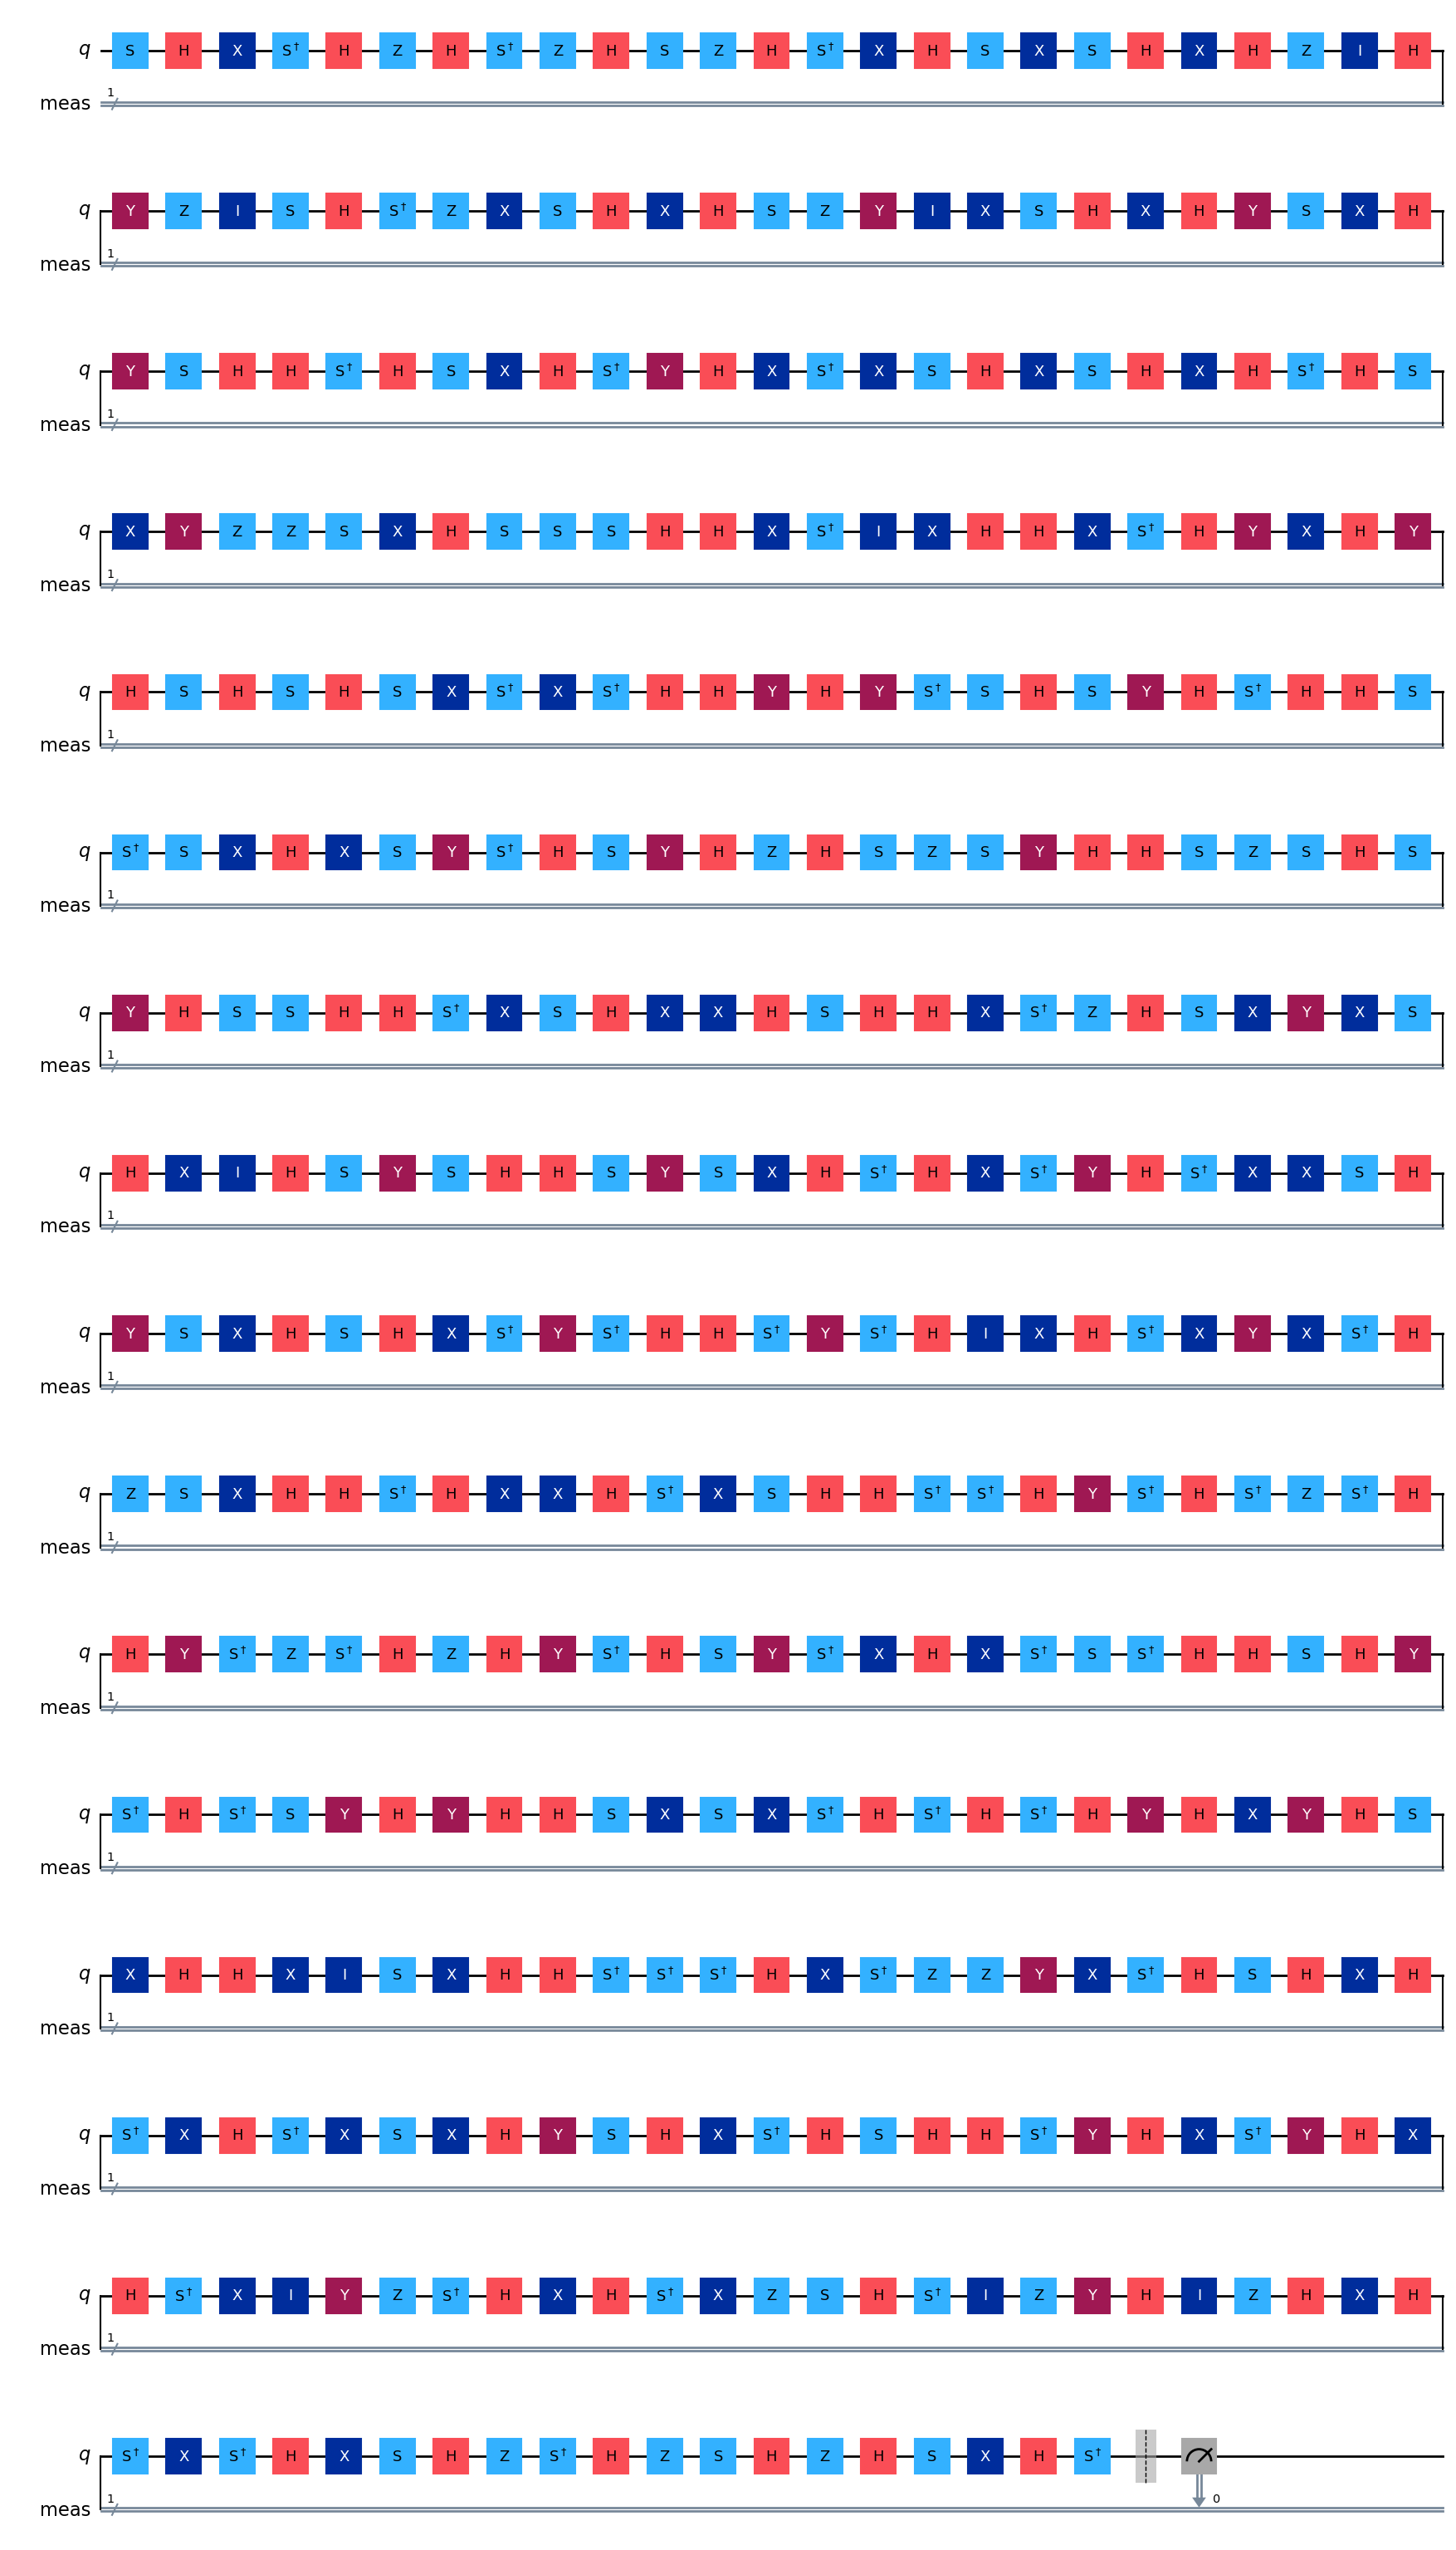

In [4]:
def random_clifford():
    return cliffords[np.random.randint(0, len(cliffords))]

qc = QuantumCircuit(1)

selected_cliffords = [random_clifford() for _ in range(100)]
print(selected_cliffords)
for i in range(len(selected_cliffords) - 1, -1, -1):
    apply_clifford(qc, selected_cliffords[i])
for i in range(len(selected_cliffords)):
    apply_clifford_adjoint(qc, selected_cliffords[i])
qc.measure_all()
qc.draw("mpl")


In [ ]:


# Measure the classical bits by appending measurements to the circuit
qc_with_measure = qc.copy()
qc_with_measure.measure_all()

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)

# 3. Transpile to that backend
tqc = transpile(qc, backend=backend, initial_layout=[0], optimization_level=0)

# 4. Run it
sampler = SamplerV2(mode=backend)
job = sampler.run([tqc], shots=1000)
print(f'Job End: {time.time() - start} seconds')

# 5. Get results
result = job.result()
counts = result[0].data.meas.get_counts()


NameError: name 'time' is not defined

In [182]:
selected_cliffords = [random_clifford() for _ in range(100)]
print(selected_cliffords)

['I', 'I', 'HY', 'Z', 'YH', 'X', 'XS', 'ZH', 'Z', 'XsH', 'sXH', 'XHSX', 'I', 'ZSH', 'H', 'S', 'YSH', 'ZH', 'YH', 'SH', 'S', 'XsH', 'Y', 'YS', 'XH', 'I', 'SH', 'XS', 'Hs', 'HS', 'X', 'ZSH', 'YH', 'Hs', 'XSH', 'Z', 'XH', 'XH', 'sH', 'YSH', 'I', 'XSH', 'XHSX', 'YSH', 'HY', 'XH', 'Hs', 'YS', 'ZSH', 'Z', 'YSH', 'Z', 'YH', 'sXH', 'H', 'XS', 'S', 'XH', 'YSH', 'Hs', 'Hs', 'XS', 'XHSX', 'YH', 'Hs', 'XsH', 'XHSX', 'HX', 'HX', 'XHSX', 'sXH', 'Z', 'ZSH', 'sH', 'ZH', 'ZSH', 'HY', 'YH', 'XsH', 'XSH', 'H', 'XSH', 'XS', 'YH', 'X', 'Z', 'YSH', 'YH', 'I', 'XH', 'XSH', 'I', 'sH', 'sH', 'HX', 'X', 'S', 'ZSH', 'XHSX', 'XS']


In [9]:
nshots = 1000
nsamples = 10
ms = [1, 2, 5, 10, 20, 50, 100, 200, 500]

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
sampler = SamplerV2(mode=backend)
results = []
for m in tqdm(ms):
    for i in range(nsamples):
        
        # Build circuit
        qc = QuantumCircuit(1)
        selected_cliffords = [random_clifford() for _ in range(m)]
        for i in range(len(selected_cliffords) - 1, -1, -1):
            apply_clifford(qc, selected_cliffords[i])
        for i in range(len(selected_cliffords)):
            apply_clifford_adjoint(qc, selected_cliffords[i])
        qc.measure_all()

        # Transpile
        tqc = transpile(qc, backend=backend, initial_layout=[0], optimization_level=0)

        # Run
        sampler = SamplerV2(mode=backend)
        job = sampler.run([tqc], shots=nshots)
        result = job.result()
        counts = result[0].data.meas.get_counts()

        # Store
        results.append((m, i, counts, selected_cliffords))

results


100%|██████████| 9/9 [14:02<00:00, 93.65s/it] 


[(1, 0, {'0': 993, '1': 7}, ['ZSH']),
 (1, 0, {'0': 991, '1': 9}, ['HS']),
 (1, 0, {'0': 986, '1': 14}, ['XHSX']),
 (1, 0, {'0': 995, '1': 5}, ['X']),
 (1, 0, {'0': 992, '1': 8}, ['XS']),
 (1, 0, {'0': 993, '1': 7}, ['X']),
 (1, 0, {'0': 981, '1': 19}, ['XHSX']),
 (1, 0, {'0': 994, '1': 6}, ['H']),
 (1, 0, {'0': 995, '1': 5}, ['ZH']),
 (1, 0, {'0': 998, '1': 2}, ['s']),
 (2, 1, {'0': 920, '1': 80}, ['YS', 'XsH']),
 (2, 1, {'0': 974, '1': 26}, ['HX', 'sH']),
 (2, 1, {'0': 985, '1': 15}, ['sXH', 'X']),
 (2, 1, {'0': 967, '1': 33}, ['Hs', 'HX']),
 (2, 1, {'0': 978, '1': 22}, ['XHSX', 'Hs']),
 (2, 1, {'0': 950, '1': 50}, ['YS', 'XSH']),
 (2, 1, {'0': 985, '1': 15}, ['ZSH', 'SH']),
 (2, 1, {'0': 984, '1': 16}, ['XH', 'XH']),
 (2, 1, {'0': 971, '1': 29}, ['HX', 'ZSH']),
 (2, 1, {'0': 979, '1': 21}, ['ZSH', 'HX']),
 (5, 4, {'0': 973, '1': 27}, ['H', 'XHSX', 'Z', 'HS', 'Z']),
 (5, 4, {'0': 954, '1': 46}, ['ZH', 'XHSX', 'ZSH', 'HX', 'X']),
 (5, 4, {'0': 980, '1': 20}, ['YS', 'HY', 'X', 'ZSH', '

In [14]:
results

[(1, 0, {'0': 993, '1': 7}, ['ZSH']),
 (1, 0, {'0': 991, '1': 9}, ['HS']),
 (1, 0, {'0': 986, '1': 14}, ['XHSX']),
 (1, 0, {'0': 995, '1': 5}, ['X']),
 (1, 0, {'0': 992, '1': 8}, ['XS']),
 (1, 0, {'0': 993, '1': 7}, ['X']),
 (1, 0, {'0': 981, '1': 19}, ['XHSX']),
 (1, 0, {'0': 994, '1': 6}, ['H']),
 (1, 0, {'0': 995, '1': 5}, ['ZH']),
 (1, 0, {'0': 998, '1': 2}, ['s']),
 (2, 1, {'0': 920, '1': 80}, ['YS', 'XsH']),
 (2, 1, {'0': 974, '1': 26}, ['HX', 'sH']),
 (2, 1, {'0': 985, '1': 15}, ['sXH', 'X']),
 (2, 1, {'0': 967, '1': 33}, ['Hs', 'HX']),
 (2, 1, {'0': 978, '1': 22}, ['XHSX', 'Hs']),
 (2, 1, {'0': 950, '1': 50}, ['YS', 'XSH']),
 (2, 1, {'0': 985, '1': 15}, ['ZSH', 'SH']),
 (2, 1, {'0': 984, '1': 16}, ['XH', 'XH']),
 (2, 1, {'0': 971, '1': 29}, ['HX', 'ZSH']),
 (2, 1, {'0': 979, '1': 21}, ['ZSH', 'HX']),
 (5, 4, {'0': 973, '1': 27}, ['H', 'XHSX', 'Z', 'HS', 'Z']),
 (5, 4, {'0': 954, '1': 46}, ['ZH', 'XHSX', 'ZSH', 'HX', 'X']),
 (5, 4, {'0': 980, '1': 20}, ['YS', 'HY', 'X', 'ZSH', '

In [13]:
# List jobs
jobs = service.jobs(limit=2)   # adjust limit as needed

for job in jobs:
    print(job.job_id(), job.status(), job.backend())
    print(job.inputs.get("circuits", None)[0].depth())
    print(job.result()[0].data.meas.get_counts())

d7jkj1solufs73etnnjg DONE <IBMBackend('ibm_fez')>


TypeError: 'NoneType' object is not subscriptable

In [15]:
import pandas as pd
df = pd.DataFrame(results)
df.to_csv("results3.csv", index=False)
